# Execution Tca Strategy Backtest

This notebook demonstrates the Execution algorithms and transaction cost analysis.

In [3]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from execution_algo import *

In [4]:
# Load data
ticker = 'SPY'
data = yf.download(ticker, start='2022-01-01', end='2023-12-31')
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data.columns = [c.lower() for c in data.columns]
data.head()

[*********************100%***********************]  1 of 1 completed


,close,high,low,open,volume
Date,,,,,
2022-01-03,451.875122,452.007565,448.223887,450.541372,72668200
2022-01-04,451.723846,454.022453,449.860384,453.303545,71178700
2022-01-05,443.049774,452.130607,442.955176,451.354946,104538900
2022-01-06,442.633545,445.357798,440.259278,442.586260,86858900
2022-01-07,440.883575,443.825400,439.521449,442.643001,85111600


In [5]:
# Initialize strategy
strategy = ExecutionTcaStrategy()

# Run backtest
results = strategy.backtest(data)
print('Metrics:', results['metrics'])

Metrics: {'total_return': 0.0, 'sharpe_ratio': 0, 'max_drawdown': 0.0, 'total_trades': 0}


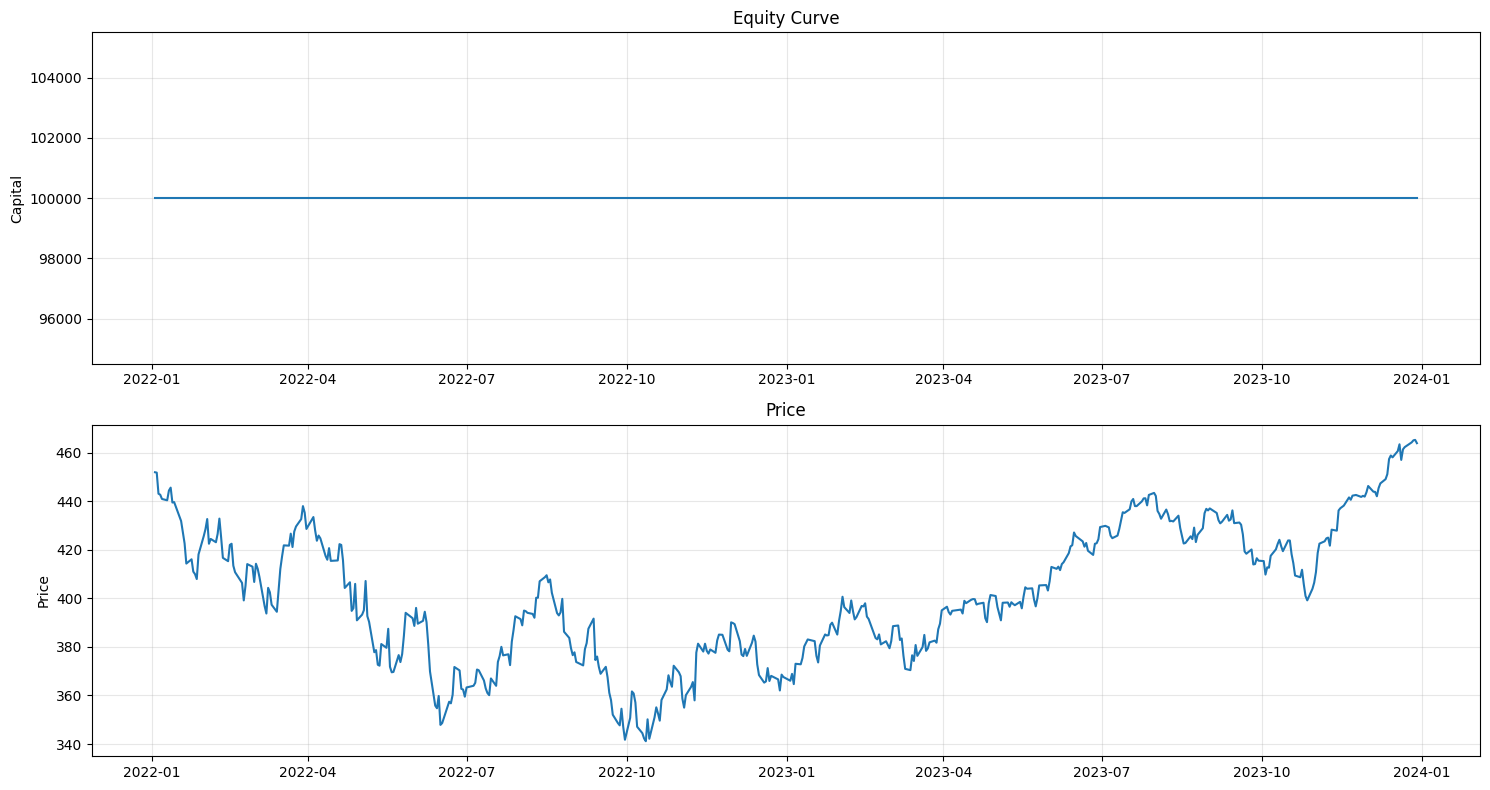

In [6]:
# Plot results
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(results['results'].index, results['results']['capital'])
plt.title('Equity Curve')
plt.ylabel('Capital')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(results['results'].index, results['results']['close'])
plt.title('Price')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()